# 3. Model Analysis

This notebook analyzes model predictions and investigates individual creatures.

**Input:**
- `helper_files/engineered_features.parquet`
- `pickled_models/hp_model_cr*.pkl`

**Output:**
- `data/engineered_features.csv`
- `data/feature_contributions.csv`

## Imports and Configs

In [1]:
import numpy as np
import os
import pandas as pd
import sys

from pathlib import Path

In [2]:
# Detect execution context and set paths dynamically
sys.path.insert(0, '.')

# Get the current working directory
cwd = Path.cwd()

# Check if we're in the notebooks directory or project root
if cwd.name == 'notebooks':
    # Running from notebooks directory (in Jupyter)
    DATA_DIR = '../data'
    PICKLED_MODELS_DIR = '../pickled_models'
    MONSTER_BUILDER_DIR = '../monster-builder-v2'
    HELPERS_DIR = './helper_files'
    IO_DIR = './notebooks_io'
    IN_NB_DIR = False
else:
    # Running from project root (via run_three_tier_model.py)
    DATA_DIR = './data'
    PICKLED_MODELS_DIR = './pickled_models'
    MONSTER_BUILDER_DIR = './monster-builder-v2'
    HELPERS_DIR = './notebooks/helper_files'
    IO_DIR = './notebooks/notebooks_io'
    IN_NB_DIR = False

print(f"📁 Execution context detected:")
print(f"   Current directory: {cwd}")
print(f"   Data directory: {DATA_DIR}")
print(f"   Models directory: {PICKLED_MODELS_DIR}")

print("Imports successful")

📁 Execution context detected:
   Current directory: /workspaces/matrix_v0
   Data directory: ./data
   Models directory: ./pickled_models
Imports successful


In [3]:
# Add helper_files to path
if IN_NB_DIR is True:
    from helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS
    )

    print("Imports successful")
else:
    from notebooks.helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS
    )

    print("Imports successful")


Imports successful


## Load Data and Models

In [4]:
import_path = DATA_DIR + '/engineered_features.csv'
df = pd.read_csv(import_path)
df['has_feature_mods'] = df[[c for c in df.columns if 'feature_' in c]].sum(axis=1) > 0

In [5]:
import_path = DATA_DIR + '/feature_contributions.csv'
contributions_df = pd.read_csv(import_path)

In [6]:
phase3_features = get_phase3_features()

In [7]:
results = {}
load_path = PICKLED_MODELS_DIR + "/hp_model_tier.pkl"
# Save each model
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:

    filepath = load_path.replace('tier', tier)
    results[tier] = load_model(filepath)
    print(f"Loaded {tier} model to {filepath}")

print("\nAll models loaded successfully!")

Loaded cr1 model to ./pickled_models/hp_model_cr1.pkl
Loaded cr2 model to ./pickled_models/hp_model_cr2.pkl
Loaded cr3 model to ./pickled_models/hp_model_cr3.pkl
Loaded cr4 model to ./pickled_models/hp_model_cr4.pkl
Loaded cr5 model to ./pickled_models/hp_model_cr5.pkl

All models loaded successfully!


In [8]:
results['cr1'].keys()


dict_keys(['model', 'scaler', 'feature_names', 'train_count', 'test_r2', 'test_mae'])

## Model Analysis

In [9]:
summarize_model_performance(results)


5-BUCKET HP MODEL TRAINING COMPLETE

MODEL PERFORMANCE SUMMARY:

   CR < 1 Model:
      Training samples: 113
      Test R²:  0.3730
      Test MAE: 5.14 HP

   CR 1-4 Model:
      Training samples: 99
      Test R²:  0.2476
      Test MAE: 14.89 HP

   CR 5-10 Model:
      Training samples: 65
      Test R²:  -0.4035
      Test MAE: 30.89 HP

   CR 11-16 Model:
      Training samples: 27
      Test R²:  0.3051
      Test MAE: 21.93 HP

   CR > 16 Model:
      Training samples: 20
      Test R²:  0.5001
      Test MAE: 76.91 HP

All 5 models trained successfully!


In [10]:
# Display top feature coefficients for each tier
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:
    print(f"\n{tier.upper()} Top Features by Coefficient:")
    coefs = results[tier]['model'].coef_
    coef_df = pd.DataFrame({
        'feature': phase3_features,
        'coefficient': coefs
    }).sort_values('coefficient', key=abs, ascending=False)
    
    print(coef_df.head(10).to_string(index=False))


CR1 Top Features by Coefficient:
               feature  coefficient
      has_spellcasting    -1.980438
     spellcaster_level     1.768409
    inflicts_petrified    -1.458634
      inflicts_blinded    -1.296748
    inflicts_paralyzed    -1.018891
   total_ability_count    -0.565442
   vulnerability_count     0.515602
           trait_count     0.429079
size_ordinal_deviation     0.379629
   inflicts_frightened    -0.142971

CR2 Top Features by Coefficient:
               feature  coefficient
      inflicts_charmed    -5.777907
      has_spellcasting    -4.576694
     spellcaster_level     3.569774
    inflicts_petrified    -3.115054
   vulnerability_count     2.830653
    inflicts_paralyzed    -1.885808
size_ordinal_deviation     1.419786
   total_ability_count    -0.821526
     inflicts_poisoned    -0.517649
           trait_count     0.190303

CR3 Top Features by Coefficient:
               feature  coefficient
      has_spellcasting   -22.746092
           trait_count   -15.95321

## Investigate Specific Creatures

In [11]:
# df[df['Name'].str.contains('Dragon')].head()

In [23]:
# Interactive investigation
# Uncomment and modify to investigate specific creatures:
# Oni, Unicorn way too penalized for different reasons.
investigate_creature('Kobold', df, contributions_df)

  KOBOLD (CR 0.125)

Actual HP:               5
Predicted HP:            7
Error:                   2  (  35.5%)

--------------------------------------------------------------------------------

PHASE 1: CR BASELINE
  HP Baseline (CR 0.125):                                14
  HP after Phase 1:                                      14

PHASE 2: COMBAT STATS

  Deviation Breakdown:
    Stat         Estimated   Feature    Total  Baseline  Deviation
    ------------------------------------------------------------
    AC                  12        +0       12        11         +1
    Attack               4        +1        5         3         +2
    DPR                  4        +0        4         3         +2
    Save DC              0        --        0        11         +0

  Costed DMG Features:
    feature_ac (+0):  (none)
    feature_attack (+1):  pack_tactics +1
    feature_dpr (+0):  (none)
    feature_hp (+0):  (none)

  HP Penalties:
    ac_deviation                        value

In [13]:
df[df['Name']=='Cloaker'][[c for c in df.columns if 'dpr' in c]]

,dpr_baseline,estimated_dpr,feature_dpr,legendary_dpr,total_dpr,dpr_deviation
262,53.0,17.5,0.0,0,17.5,-35.5


In [14]:
# _df = analysis_dfs['cr3']
# _df.sort_values('predicted_hp')

In [15]:
# List worst predictions
# print("\nWorst Over-predictions (predicted > actual):")
# over_pred = df[df['hp_delta'] > 0].nlargest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(over_pred.to_string(index=False))

# print("\nWorst Under-predictions (predicted < actual):")
# under_pred = df[df['hp_delta'] < 0].nsmallest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(under_pred.to_string(index=False))

# print("\nBest Predictions:")
# df_check_best = df[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']].copy()
# df_check_best['hp_delta_pct_abs'] = df_check_best['hp_delta_pct'].abs()
# best = df_check_best.nsmallest(10, 'hp_delta_pct_abs')
# print(best.to_string(index=False))

# Deatiled Model Breakdown

In [16]:
analysis_dfs = analyze_predictions_by_cr(df)



CR < 1 - Best 10 Predictions:
        Name    CR  Actual_HP  Predicted_HP     Error
  Cockatrice 0.500         27     26.999997  0.000003
     Cultist 0.125          9      8.999995  0.000005
      Stirge 0.125          2      1.920499  0.079501
    Commoner 0.000          4      3.728603  0.271397
         Owl 0.000          1      0.641421  0.358579
Magma Mephit 0.500         22     21.282126  0.717874
 Dust Mephit 0.500         17     17.764965 -0.764965
   Giant Rat 0.125          7      6.170474  0.829526
  Blood Hawk 0.125          7      6.170474  0.829526
      Shadow 0.500         16     15.156977  0.843023

CR < 1 - Worst 10 Predictions:
                 Name   CR  Actual_HP  Predicted_HP      Error
               Dretch 0.25         18      7.447861  10.552139
                Scout 0.50         16     26.608772 -10.608772
        Swarm of Bats 0.25         22     11.351091  10.648909
                  Orc 0.50         15     25.733772 -10.733772
Giant Poisonous Snake 0.25  

In [17]:
_df_check = analysis_dfs['cr2']
[c for c in _df_check.columns if 'immun' in c]


['hp_after_resist_immun_penalty',
 'immunity_count',
 'feature_spell_immunity',
 'feature_turn_immunity']

In [18]:
# _df_check = analysis_dfs['cr2']
# _df_check[_df_check['actual_hp'] == 45]



📊 VISUALIZATION: Actual vs Predicted HP (5 CR Buckets)


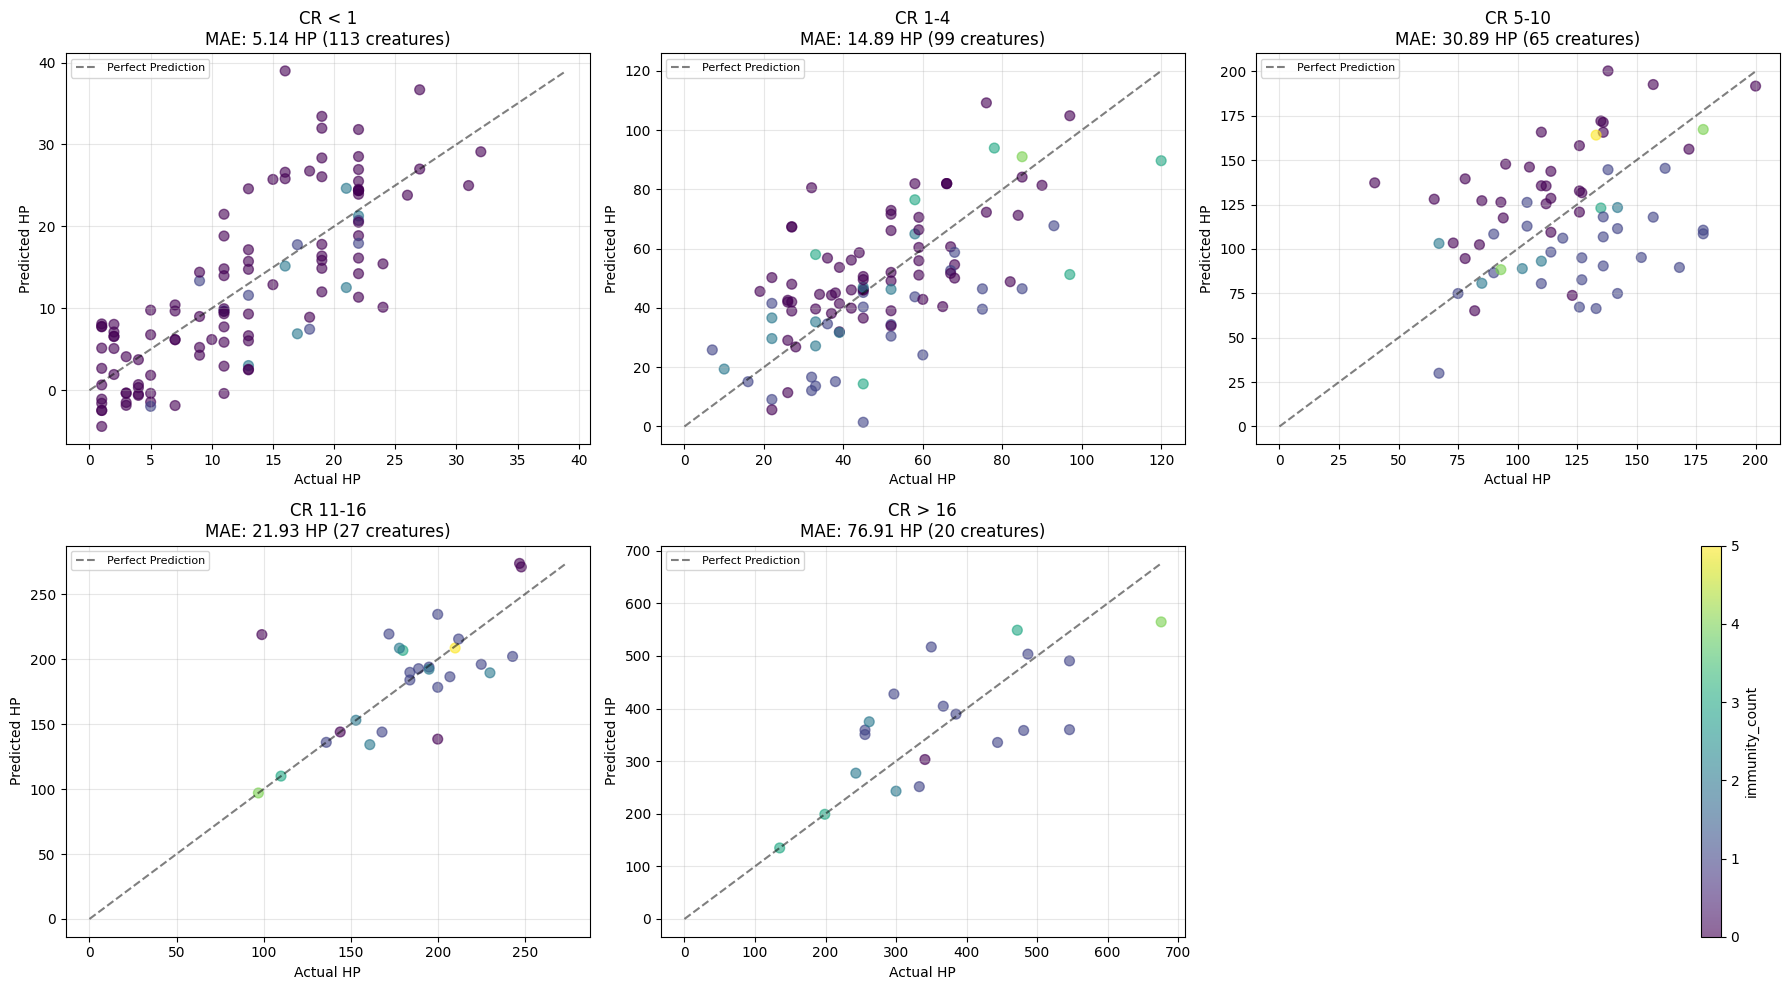

In [19]:

plot_performance_scatter(analysis_dfs, highlight_feature='immunity_count')

In [20]:
for k, v in df[df['Name']=='Hill Giant'][[c for c in df.columns if 'feature' in c]].iloc[0].items():
    print(f"{k}: {v}")

feature_dpr: 0.0
feature_ac: 0
feature_attack: 0
feature_hp: 0.0
feature_aggressive: 0
feature_ambusher: 0
feature_amorphous: 0
feature_amphibious: 0
feature_angelic_weapons: 0
feature_antimagic_susceptibility: 0
feature_avoidance: 0
feature_blind_senses: 0
feature_blood_frenzy: 0
feature_breath_weapon: 0
feature_brute: 0
feature_charge: 0
feature_charm: 0
feature_constrict: 0
feature_damage_absorption: 0
feature_damage_transfer: 0
feature_death_burst: 0
feature_devils_sight: 0
feature_dive_attack: 0
feature_echolocation: 0
feature_elemental_body: 0
feature_enlarge: 0
feature_etherealness: 0
feature_false_appearance: 0
feature_fey_ancestry: 0
feature_fiendish_blessing: 0
feature_flyby: 0
feature_frightful_presence: 0
feature_grapple: 0
feature_grappler: 0
feature_hold_breath: 0
feature_horrifying_visage: 0
feature_illumination: 0
feature_immutable_form: 0
feature_incorporeal_movement: 0
feature_innate_spellcasting: 0
feature_invisibility: 0
feature_keen_senses: 0
feature_labyrinthine_r

In [21]:
_df = analysis_dfs['cr3']
_df.sort_values('predicted_hp')

,Name,cr_numeric,actual_hp,predicted_hp,hp_delta,hp_delta_pct,hp_delta_pct_percentile,hp_baseline,ac_baseline,attack_baseline,...,has_attackers_advantage,inflicts_prone,has_grapple,has_feature_mods,Actual_HP,Predicted_HP,CR,Error,Abs_Error,Pct_Error
23,Unicorn,5.0,67,29.963788,-37.036212,-55.277928,93.846154,114.0,15.0,7.0,...,0,1,0,True,67,29.963788,5.0,37.036212,37.036212,55.277928
17,Vampire Spawn,5.0,82,65.162809,-16.837191,-20.533160,38.461538,114.0,15.0,7.0,...,0,0,1,True,82,65.162809,5.0,16.837191,16.837191,20.533160
27,Young White Dragon,6.0,133,66.411414,-66.588586,-50.066606,89.230769,134.4,15.0,7.0,...,0,0,0,True,133,66.411414,6.0,66.588586,66.588586,50.066606
22,Earth Elemental,5.0,126,67.206651,-58.793349,-46.661388,83.076923,114.0,15.0,7.0,...,0,0,0,True,126,67.206651,5.0,58.793349,58.793349,46.661388
26,Drider,6.0,123,73.795682,-49.204318,-40.003511,78.461538,134.4,15.0,7.0,...,0,0,0,True,123,73.795682,6.0,49.204318,49.204318,40.003511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47,Tyrannosaurus Rex,8.0,136,171.269361,35.269361,25.933354,61.538462,163.2,15.0,7.0,...,0,0,1,False,136,171.269361,8.0,-35.269361,35.269361,-25.933354
64,Aboleth,10.0,135,172.035899,37.035899,27.433999,66.153846,186.0,17.0,9.0,...,0,0,0,True,135,172.035899,10.0,-37.035899,37.035899,-27.433999
57,Cloud Giant,9.0,200,191.687898,-8.312102,-4.156051,7.692308,174.0,16.0,8.0,...,0,0,0,True,200,191.687898,9.0,8.312102,8.312102,4.156051
39,Giant Ape,7.0,157,192.574168,35.574168,22.658706,50.769231,156.0,15.0,7.0,...,0,0,0,False,157,192.574168,7.0,-35.574168,35.574168,-22.658706



📊 VISUALIZATION: Error Distribution (5 CR Buckets)


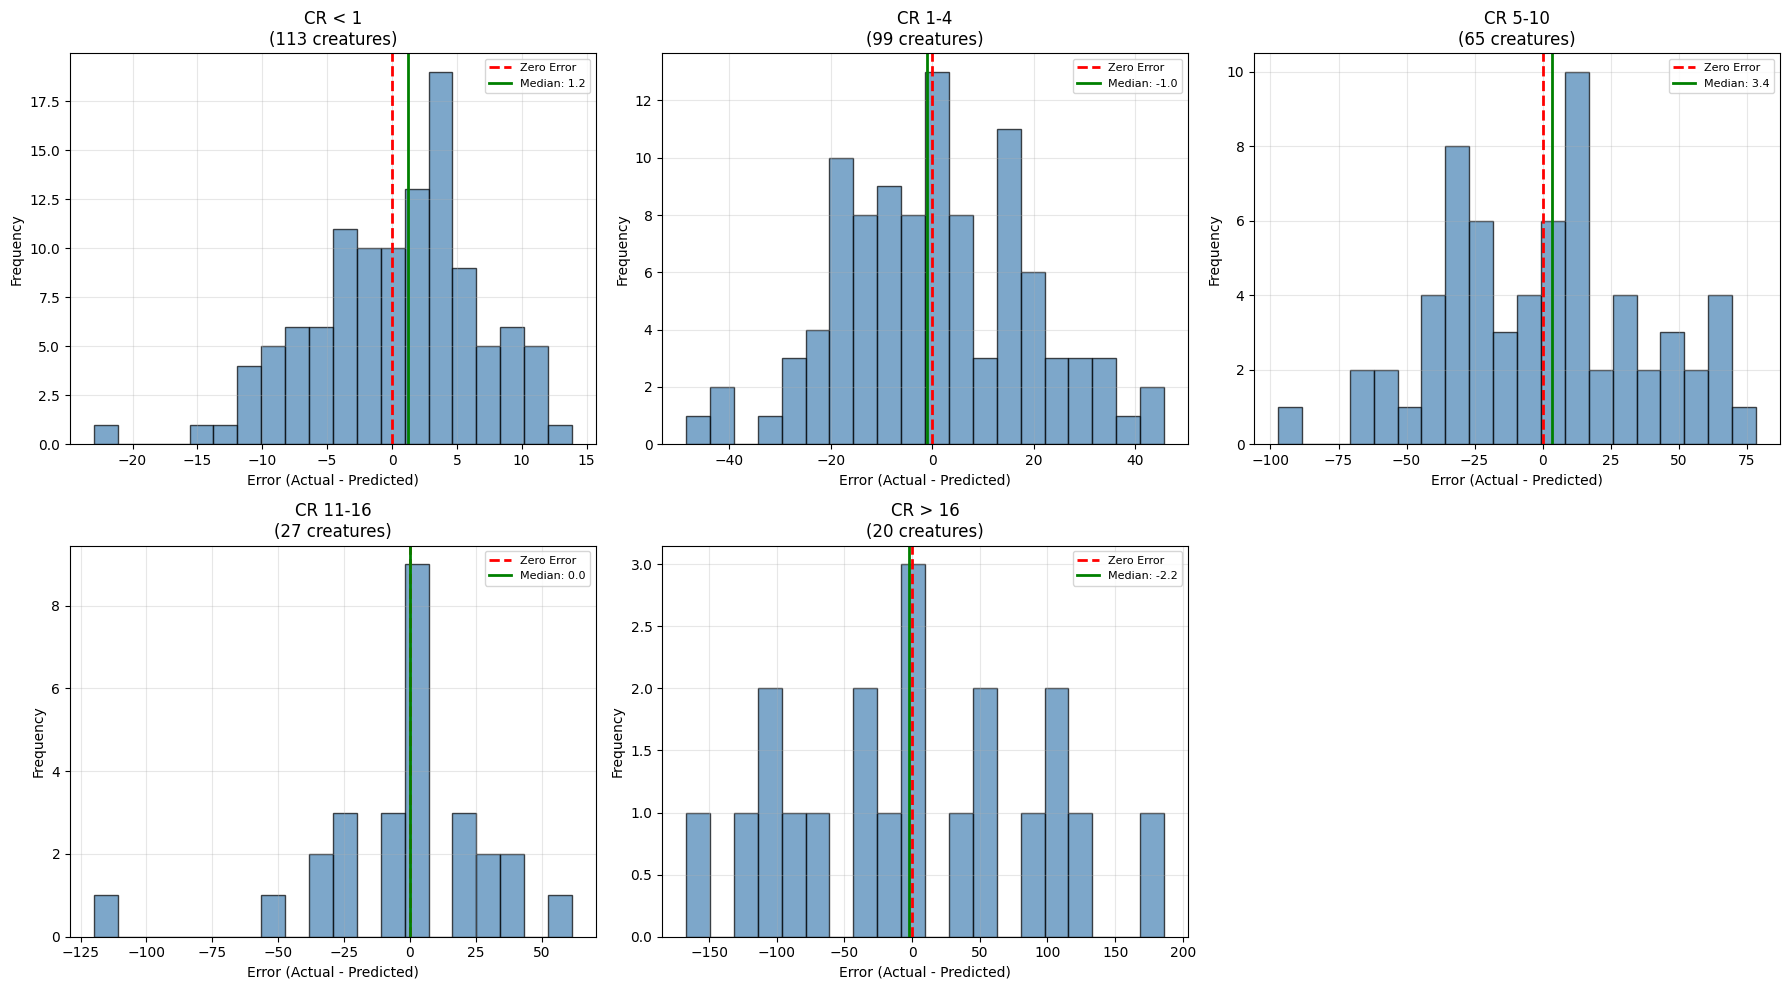

In [22]:
plot_error_hist(analysis_dfs)